In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
df = pd.read_csv("C:/Users/USUARIO/Documents/Codigos/Análisis de datos con Python/resources/laptop_pricing_dataset_mod1.csv")

print(df.info())
print(df.head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    object 
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    object 
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  234 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       233 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 24.3+ KB
None
   Unnamed: 0 Manufacturer  Category     Screen  GPU  OS  CPU_core  \
0           0         Acer         4  IPS Panel    2   1         5   
1           

In [11]:
df[['Screen_Size_cm']] = np.round(df[['Screen_Size_cm']],2)
df

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.62,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.62,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.78,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.62,1.8,8,256,1.91,837
...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,233,Lenovo,4,IPS Panel,2,1,7,35.56,2.6,8,256,1.70,1891
234,234,Toshiba,3,Full HD,2,1,5,33.78,2.4,8,256,1.20,1950
235,235,Lenovo,4,IPS Panel,2,1,5,30.48,2.6,8,256,1.36,2236
236,236,Lenovo,3,Full HD,3,1,5,39.62,2.5,6,256,2.40,883


In [15]:
print(df["Weight_kg"].unique())
# missing_data = df.isnull()
# missing_data

[1.6  2.2  1.22 1.91 2.1  2.3  2.13 2.   1.7  1.4  1.86 1.88 1.63 1.83
 1.96 1.21 2.65 1.25 1.38  nan 1.3  1.58 2.5  1.75 1.48 3.   1.05 1.12
 1.2  2.56 3.6  1.41 2.05 1.95 3.42 1.1  1.26 1.84 2.6  1.36 2.33 1.5
 2.7  1.9  1.43 2.31 1.64 2.17 1.65 2.67 1.42 1.78 1.49 1.44 1.29 2.04
 1.32 2.02 1.93 1.87 3.4  2.06 2.18 1.8  1.56 2.63 0.81 2.59 1.18 1.31
 2.62 3.14 2.37 2.4  1.23 1.28 1.17 1.47]


In [16]:
missing_data = df.isnull()
print(missing_data.head())
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")    

   Unnamed: 0  Manufacturer  Category  Screen    GPU     OS  CPU_core  \
0       False         False     False   False  False  False     False   
1       False         False     False   False  False  False     False   
2       False         False     False   False  False  False     False   
3       False         False     False   False  False  False     False   
4       False         False     False   False  False  False     False   

   Screen_Size_cm  CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_kg  Price  
0           False          False   False           False      False  False  
1           False          False   False           False      False  False  
2           False          False   False           False      False  False  
3           False          False   False           False      False  False  
4           False          False   False           False      False  False  
Unnamed: 0
Unnamed: 0
False    238
Name: count, dtype: int64

Manufacturer
Manufacturer
False    23

In [23]:

#MEAN
avg_Weight_kg = df["Weight_kg"].astype("float").mean(axis=0)
print("Average of Weight_kg:", avg_Weight_kg)

common_screen_size = df['Screen_Size_cm'].value_counts().idxmax()




Average of Weight_kg: 1.8622317596566522


In [24]:
df["Weight_kg"] = (
    df["Weight_kg"]
      .replace(np.nan, avg_Weight_kg)
      .infer_objects(copy=False)
)

df["Screen_Size_cm"] = df["Screen_Size_cm"].replace(np.nan, common_screen_size)#, inplace=True)



In [25]:
df[["Weight_kg", "Screen_Size_cm"]] = df[["Weight_kg", "Screen_Size_cm"]].astype("float")

In [26]:
#standarization

df['Weight_pounds'] = df["Weight_kg"]/2.205
df['Screen_Size_in'] = df["Screen_Size_cm"]/2.54

df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Weight_pounds,Screen_Size_in
0,0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.60,978,0.725624,14.000000
1,1,Dell,3,Full HD,1,1,3,39.62,2.0,4,256,2.20,634,0.997732,15.598425
2,2,Dell,3,Full HD,1,1,7,39.62,2.7,8,256,2.20,946,0.997732,15.598425
3,3,Dell,4,IPS Panel,2,1,5,33.78,1.6,8,128,1.22,1244,0.553288,13.299213
4,4,HP,4,Full HD,2,1,7,39.62,1.8,8,256,1.91,837,0.866213,15.598425


In [27]:
df['CPU_frequency'] = df['CPU_frequency']/df['CPU_frequency'].max()
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Weight_pounds,Screen_Size_in
0,0,Acer,4,IPS Panel,2,1,5,35.56,0.551724,8,256,1.60,978,0.725624,14.000000
1,1,Dell,3,Full HD,1,1,3,39.62,0.689655,4,256,2.20,634,0.997732,15.598425
2,2,Dell,3,Full HD,1,1,7,39.62,0.931034,8,256,2.20,946,0.997732,15.598425
3,3,Dell,4,IPS Panel,2,1,5,33.78,0.551724,8,128,1.22,1244,0.553288,13.299213
4,4,HP,4,Full HD,2,1,7,39.62,0.620690,8,256,1.91,837,0.866213,15.598425


In [29]:
df["Price"]=df["Price"].astype(int, copy=True)

%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
plt.pyplot.hist(df["Price"])

# set x/y labels and plot title
plt.pyplot.xlabel("Price")
plt.pyplot.ylabel("count")
plt.pyplot.title("Price bins")



Text(0.5, 1.0, 'Price bins')

In [30]:
# binning 

bins = np.linspace(min(df["Price"]), max(df["Price"]), 4)
bins

array([ 527.        , 1621.33333333, 2715.66666667, 3810.        ])

In [32]:
group_names = ['Low', 'Medium', 'High']

df['Price-binned'] = pd.cut(df['Price'], bins, labels=group_names, include_lowest=True )
df[['Price','Price-binned']].tail(20)

,Price,Price-binned
218,1531,Low
219,1002,Low
220,1294,Low
221,1119,Low
222,1219,Low
223,1648,Medium
224,2509,Medium
225,2096,Medium
226,1480,Low
227,1404,Low


In [34]:
df["Price-binned"].value_counts()

Price-binned
Low       160
Medium     72
High        6
Name: count, dtype: int64

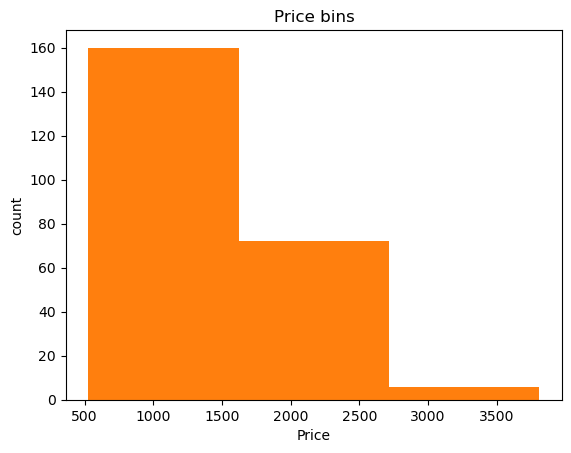

In [35]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot


# draw historgram of attribute "horsepower" with bins = 3
plt.pyplot.hist(df["Price"], bins = 3)

# set x/y labels and plot title
plt.pyplot.xlabel("Price")
plt.pyplot.ylabel("count")
plt.pyplot.title("Price bins")

pyplot.show()

In [36]:
#dummies

dummy_variable_1 = pd.get_dummies(df["Screen"])
dummy_variable_1.tail(20)

,Full HD,IPS Panel
218,True,False
219,True,False
220,True,False
221,True,False
222,True,False
223,True,False
224,False,True
225,False,True
226,True,False
227,False,True


In [37]:
dummy_variable_1.rename(columns={'Full HD':'Screen-Full_HD', 'IPS Panel':'Scree-IPS_Panel'}, inplace=True)
dummy_variable_1.tail(20)

,Screen-Full_HD,Scree-IPS_Panel
218,True,False
219,True,False
220,True,False
221,True,False
222,True,False
223,True,False
224,False,True
225,False,True
226,True,False
227,False,True


In [38]:
# merge data frame "df" and "dummy_variable_1" 
df = pd.concat([df, dummy_variable_1], axis=1)

# drop original column "fuel-type" from "df"
# df.drop("fuel-type", axis = 1, inplace=True)
df.tail(20)


,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Weight_pounds,Screen_Size_in,Price-binned,Screen-Full_HD,Scree-IPS_Panel
218,218,Dell,3,Full HD,2,1,5,35.56,0.965517,8,256,1.60,1531,0.725624,14.000000,Low,True,False
219,219,Lenovo,3,Full HD,3,1,7,39.62,0.931034,6,256,2.20,1002,0.997732,15.598425,Low,True,False
220,220,HP,3,Full HD,3,1,7,39.62,0.931034,8,256,2.04,1294,0.925170,15.598425,Low,True,False
221,221,Lenovo,3,Full HD,2,1,5,33.78,0.862069,4,128,1.44,1119,0.653061,13.299213,Low,True,False
222,222,HP,3,Full HD,2,1,5,33.78,0.862069,8,256,1.49,1219,0.675737,13.299213,Low,True,False
223,223,HP,4,Full HD,1,1,7,39.62,0.862069,8,256,1.84,1648,0.834467,15.598425,Medium,True,False
224,224,Toshiba,3,IPS Panel,3,1,7,38.10,0.896552,16,256,2.40,2509,1.088435,15.000000,Medium,False,True
225,225,Lenovo,4,IPS Panel,2,1,7,30.48,0.931034,8,256,1.36,2096,0.616780,12.000000,Medium,False,True
226,226,HP,3,Full HD,2,1,5,39.62,0.793103,8,256,2.31,1480,1.047619,15.598425,Low,True,False
227,227,Toshiba,3,IPS Panel,2,1,5,35.56,0.793103,4,128,1.47,1404,0.666667,14.000000,Low,False,True
